# Additional Figures & Tables

Main Figures and Tables

Tristan Muno [](https://orcid.org/0009-0002-3078-8436) (University of Mannheim)  
Vera Okisheva (University of Mannheim)  
Raphael Klöckner (University of Mannheim)  
June 12, 2026

## Setup

In [ ]:
#| label: setup
#| include: false
# execution time
start_time <- Sys.time()
# console width
options(width = 80)
# packages
p_required <- c(
  "tidyverse", # dplyr, ggplot2, tidyr
  "here", # relative paths
  "ggpubr", # theme_pubr
  "patchwork", # multi-panel composition
  "gtsummary",
  "gt",
  "sessioninfo" # session docs
)
packages <- rownames(installed.packages())
p_to_install <- p_required[!(p_required %in% packages)]
if (length(p_to_install) > 0) {
  install.packages(p_to_install)
}
sapply(p_required, require, character.only = TRUE)

Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: here

here() starts at C:/R/research/MBEU25

Loading required package: ggpubr

Loading required package: patchwork

Loading required package: gtsummary

Loading required package: gt

Loading required package: sessioninfo

  tidyverse        here      ggpubr   patchwork   gtsummary          gt 
       TRUE        TRUE        TRUE        TRUE        TRUE        TRUE 
sessioninfo 
       TRUE 

## Load long format data

In [ ]:
#| label: load-dat
eu25_long <- read_rds(
  here(
    "data",
    "02_processed",
    "eu25_long.rds"
  )
)

## House style

The shared visual grammar for every figure in this notebook. The two games are the only thing encoded by colour, shape, and linetype, and they are always encoded by all three at once, so each game is distinguishable in colour, in greyscale print, and under colourblindness. Any other categorical distinction (moderator family, estimator, treatment level) is carried by facets, panels, or axis position — never by reusing a game channel.

In [ ]:
#| label: game-style
# game identity: Okabe-Ito blue / orange, redundant shape + linetype
game_labs <- c(cj_dict = "Dictator game", cj_trust = "Trust game")
game_cols <- c("Dictator game" = "#0072B2", "Trust game" = "#D55E00")
game_shapes <- c("Dictator game" = 16, "Trust game" = 17) # circle / triangle
game_ltys <- c("Dictator game" = "solid", "Trust game" = "longdash")

# raw cj_game_type -> ordered, human-readable factor
lab_game <- function(x) {
  factor(unname(game_labs[as.character(x)]), levels = unname(game_labs))
}

The three reserved scales are always added together so the legend collapses to one key.

In [ ]:
#| label: game-scales
scale_colour_game <- function() {
  scale_colour_manual(values = game_cols, name = NULL)
}
scale_shape_game <- function() {
  scale_shape_manual(values = game_shapes, name = NULL)
}
scale_linetype_game <- function() {
  scale_linetype_manual(values = game_ltys, name = NULL)
}

Shared theme, reference layers, dodge width, and the common CATE y-axis label.

In [ ]:
#| label: house-theme
theme_mbeu <- function(base_size = 11) {
  ggpubr::theme_pubr(base_size = base_size) +
    theme(legend.position = "top")
}
# dashed null line for effect figures
ref_zero <- geom_hline(yintercept = 0, linetype = "dashed", colour = "grey60")
# side-by-side offset for two-game overlays
dodge <- position_dodge(width = 0.5)
# shared axis label for CATE-by-moderator figures
yl_cate <- "CATE (effect of Muslim profile)"

The golden ratio is the default figure aspect (width : height ≈ 1.618 : 1). Set chunk `fig-width`/`fig-height` from `golden` so single-panel figures share one proportion; do not apply it to faceted small multiples or auto-sized contexts.

In [ ]:
#| label: golden-ratio
golden <- (1 + sqrt(5)) / 2 # ~1.618
# figure height (in) for a given width at golden proportion
golden_h <- function(width) width / golden

## Token allocation to Muslim profiles

The motivating descriptive: how many tokens does a profile receive when it is labelled Muslim versus everything else, in each game. We summarise this three ways — a per-game Welch two-sample t-test on the raw difference in means (the sample average treatment effect, SATE), a slope/dumbbell figure of the two group means with 95% confidence intervals, and a one-row-per-game summary table of the same quantities (the version embedded in the manuscript). The test is intentionally simple and descriptive: respondent clustering is left to the heterogeneity models that follow.

In [ ]:
#| label: diff-in-means-test
# analysis frame: muslim vs all-else, readable game
dim_dat <- eu25_long |>
  mutate(
    treat = factor(
      if_else(cj_rel == "muslim", "Muslim", "Non-Muslim"),
      levels = c("Non-Muslim", "Muslim")
    ),
    game = lab_game(cj_game_type)
  )

# welch t-test per game, muslim - non-muslim
dim_test_one <- function(df) {
  tt <- t.test(cj_pl2 ~ treat, data = df) # non-muslim - muslim
  tibble(
    mean_nonmuslim = unname(tt$estimate[1]),
    mean_muslim = unname(tt$estimate[2]),
    diff = mean_muslim - mean_nonmuslim,
    conf_low = -tt$conf.int[2],
    conf_high = -tt$conf.int[1],
    t = -unname(tt$statistic),
    df = unname(tt$parameter),
    p = tt$p.value
  )
}

dim_tests <- dim_dat |>
  group_by(game) |>
  group_modify(~ dim_test_one(.x)) |>
  ungroup()

dim_tests

# A tibble: 2 × 9
  game         mean_nonmuslim mean_muslim   diff conf_low conf_high     t     df
  <fct>                 <dbl>       <dbl>  <dbl>    <dbl>     <dbl> <dbl>  <dbl>
1 Dictator ga…           3.37        2.80 -0.570   -0.606    -0.533 -30.8 35217.
2 Trust game             3.45        2.81 -0.643   -0.681    -0.605 -33.2 36872.
# ℹ 1 more variable: p <dbl>

Read the SATE numbers off `dim_tests` above and fill the placeholders in the figure caption.

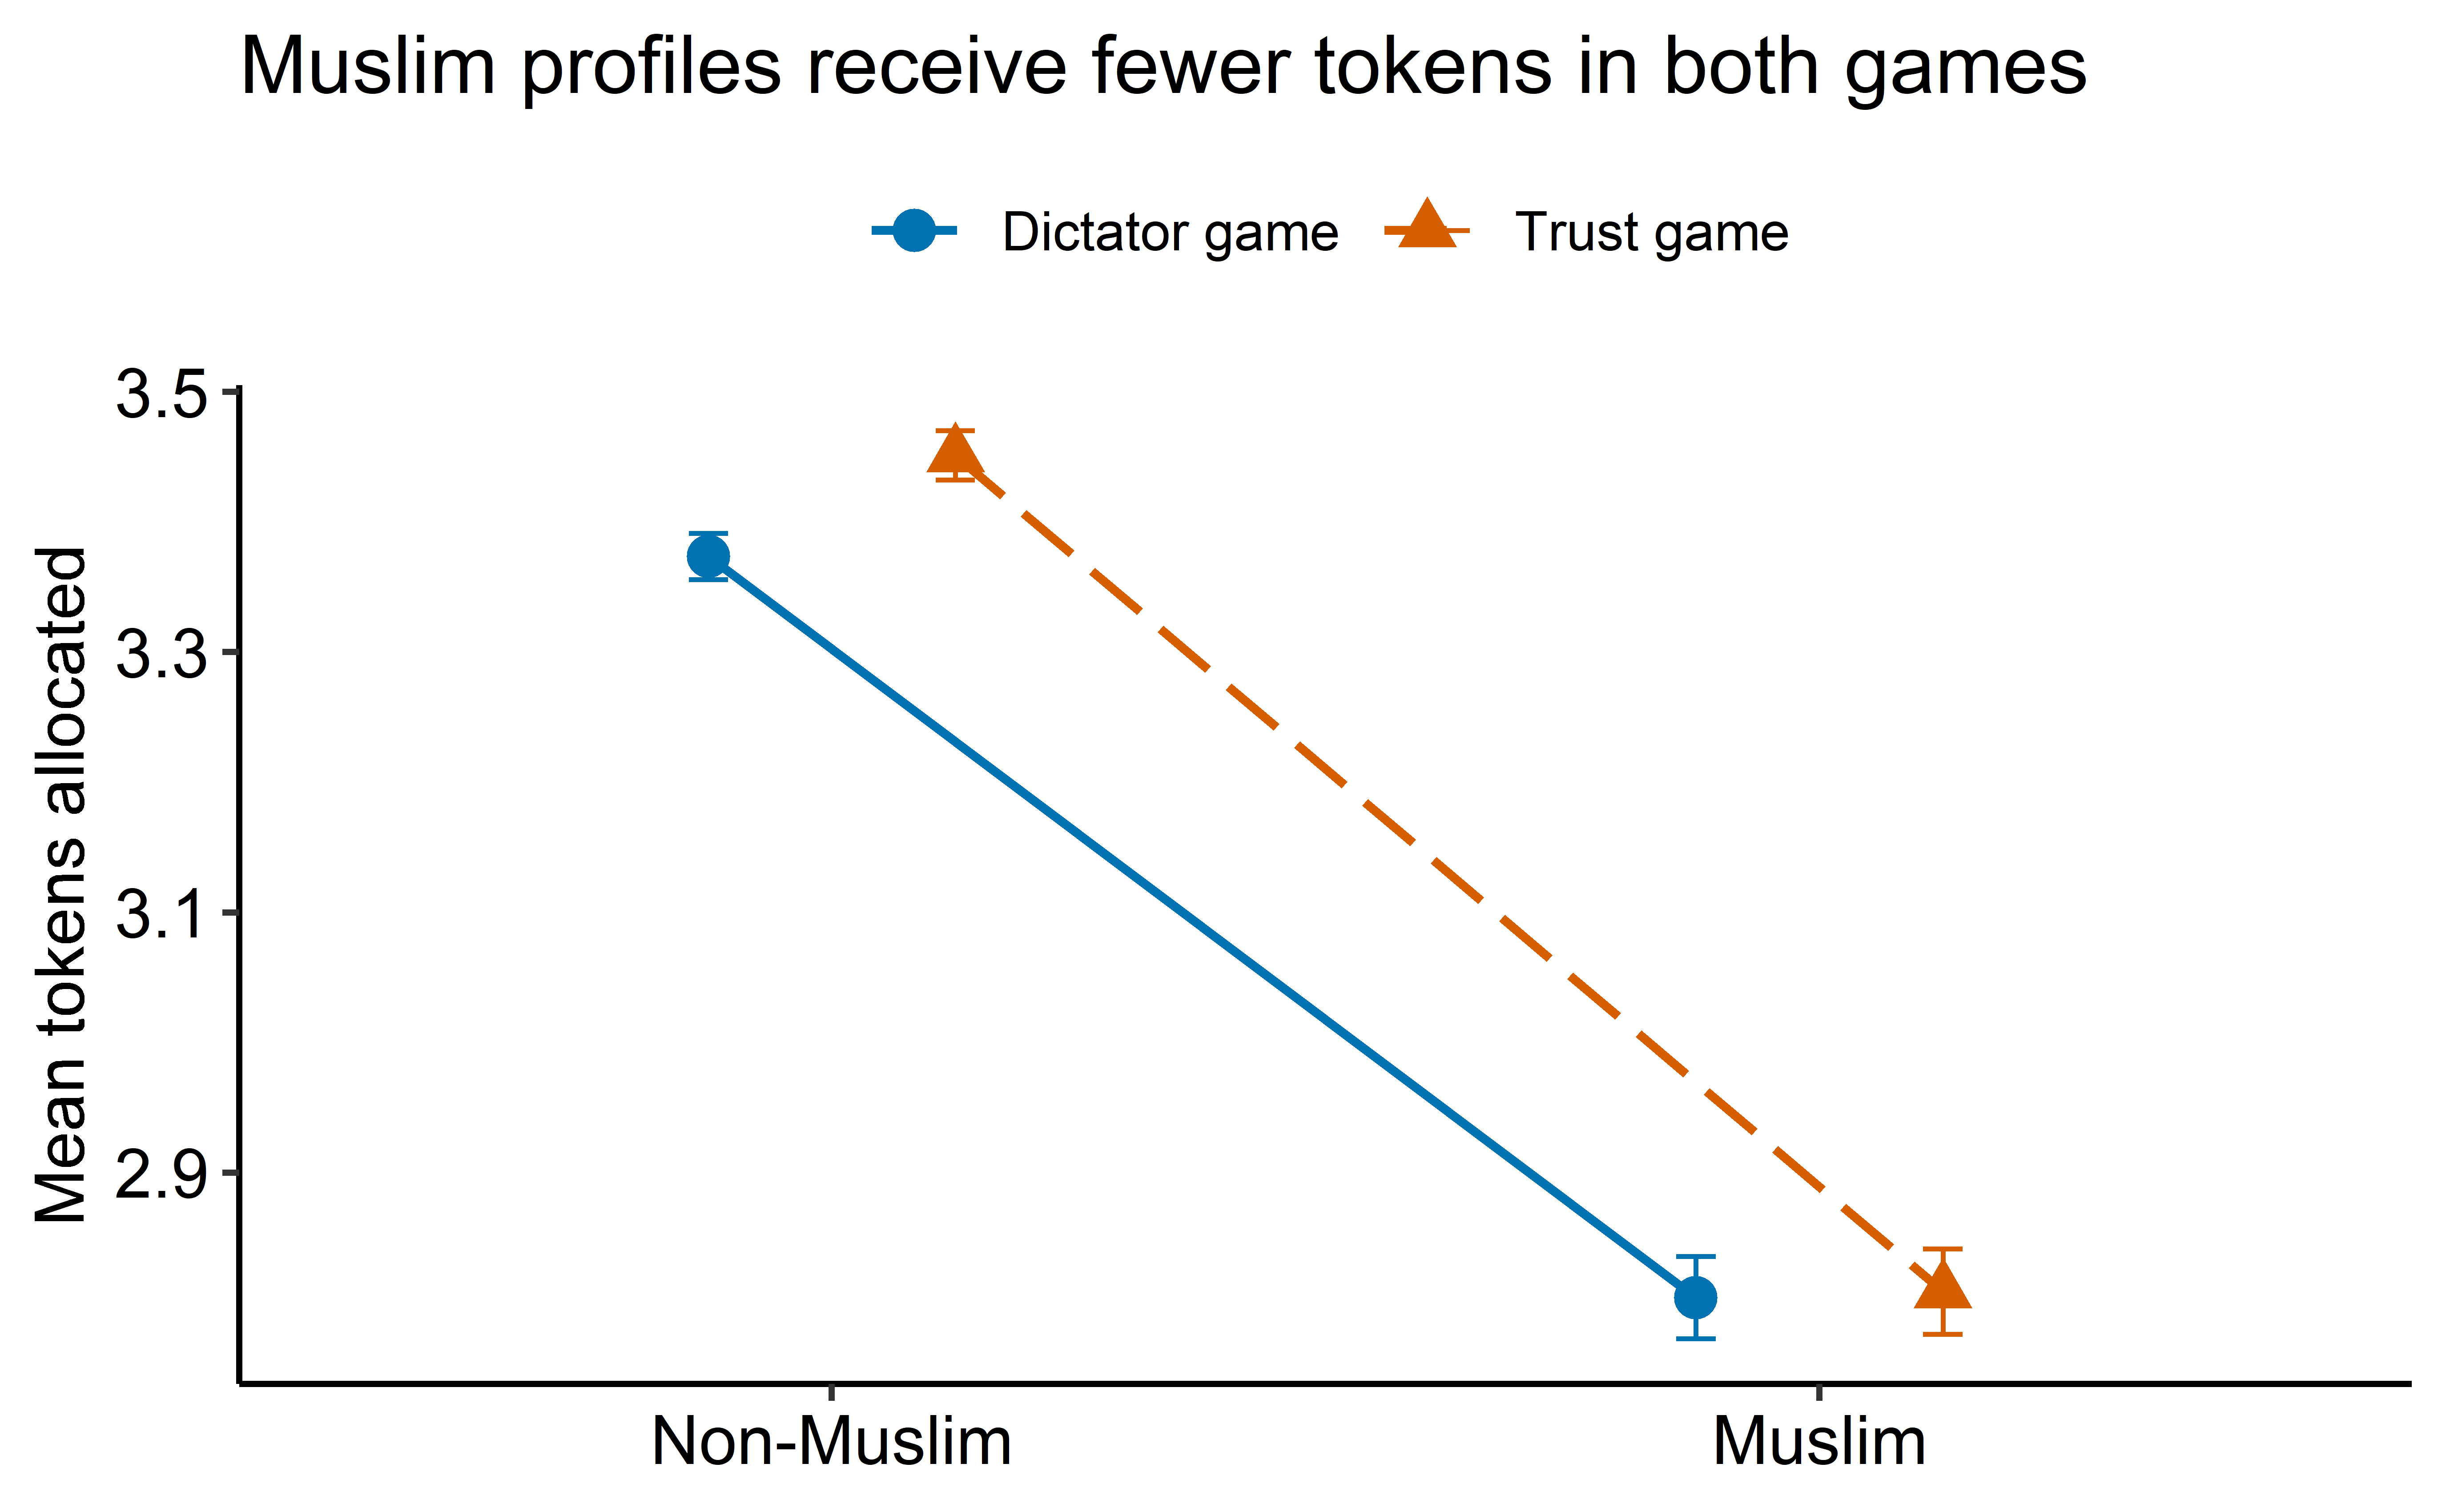

In [ ]:
#| label: fig-diff-in-means
#| fig-cap: "Mean tokens allocated to a profile by the Muslim label, by game. The outcome (y-axis) is the number of tokens the respondent allocates to the displayed profile. X-axis contrasts profiles labelled Muslim against all other religions pooled. Points are group means and error bars are 95% confidence intervals. The slope of each line is the sample average treatment effect (SATE) of the Muslim label, estimated by a per-game Welch two-sample difference-in-means t-test: $\\widehat{\\text{SATE}}_\\text{Dictator} = -0.57\\ [-0.61, -0.53]$, $\\widehat{\\text{SATE}}_\\text{Trust} = -0.64\\ [-0.68, -0.61]$."
#| fig-dpi: 500
#| fig-width: 5.5
#| fig-height: 3.4
# group means + 95% ci
dim_means <- dim_dat |>
  group_by(game, treat) |>
  summarise(
    mean_tok = mean(cj_pl2),
    se = sd(cj_pl2) / sqrt(n()),
    ci = qt(0.975, n() - 1) * se,
    .groups = "drop"
  )

dim_means |>
  ggplot(aes(
    x = treat,
    y = mean_tok,
    colour = game,
    shape = game,
    linetype = game,
    group = game
  )) +
  geom_line(position = dodge, linewidth = 0.7) +
  geom_errorbar(
    aes(ymin = mean_tok - ci, ymax = mean_tok + ci),
    position = dodge,
    width = 0.08,
    linewidth = 0.4,
    linetype = "solid"
  ) +
  geom_point(position = dodge, size = 3) +
  scale_colour_game() +
  scale_shape_game() +
  scale_linetype_game() +
  labs(
    title = "Muslim profiles receive fewer tokens in both games",
    x = NULL,
    y = "Mean tokens allocated"
  ) +
  theme_mbeu()

The summary table condenses the figure into one row per game: the two group means with their 95% confidence intervals, the per-game SATE from `dim_tests`, and its 95% confidence interval.

In [ ]:
#| label: tbl-diff-in-means
#| tbl-cap: "Mean tokens allocated to a profile by the Muslim label, by game. The outcome is the number of tokens the respondent allocates to the displayed profile. Profiles labelled Muslim are contrasted against all other religions pooled. The first two columns show group means with 95% confidence intervals in brackets. The SATE column reports the sample average treatment effect of the Muslim label, estimated by a per-game Welch two-sample difference-in-means t-test, with its 95% confidence interval alongside. The test is intentionally simple and descriptive. Respondent clustering is left to the heterogeneity models."
# one row per game: group means [ci], sate, sate ci
dim_means |>
  mutate(
    cell = sprintf("%.2f [%.2f, %.2f]", mean_tok, mean_tok - ci, mean_tok + ci)
  ) |>
  select(game, treat, cell) |>
  pivot_wider(names_from = treat, values_from = cell) |>
  left_join(dim_tests, by = "game") |>
  transmute(
    Game = game,
    Muslim,
    `Non-Muslim`,
    SATE = sprintf("%.2f", diff),
    `95% CI` = sprintf("[%.2f, %.2f]", conf_low, conf_high)
  ) |>
  knitr::kable()

  ---------------------------------------------------------------------------
  Game          Muslim             Non-Muslim         SATE    95% CI
  ------------- ------------------ ------------------ ------- ---------------
  Dictator game 2.80 \[2.77,       3.37 \[3.36,       -0.57   \[-0.61,
                2.84\]             3.39\]                     -0.53\]

  Trust game    2.81 \[2.78,       3.45 \[3.43,       -0.64   \[-0.68,
                2.84\]             3.47\]                     -0.60\]
  ---------------------------------------------------------------------------


## Outcome Distribution

The distribution of the raw outcome — tokens allocated to the displayed profile, an integer from 0 to 10 — in each game. Both games are drawn together with the reserved colour/shape/linetype grammar applied at once, and shown as within-game proportions so the two games are comparable despite differing numbers of decisions.

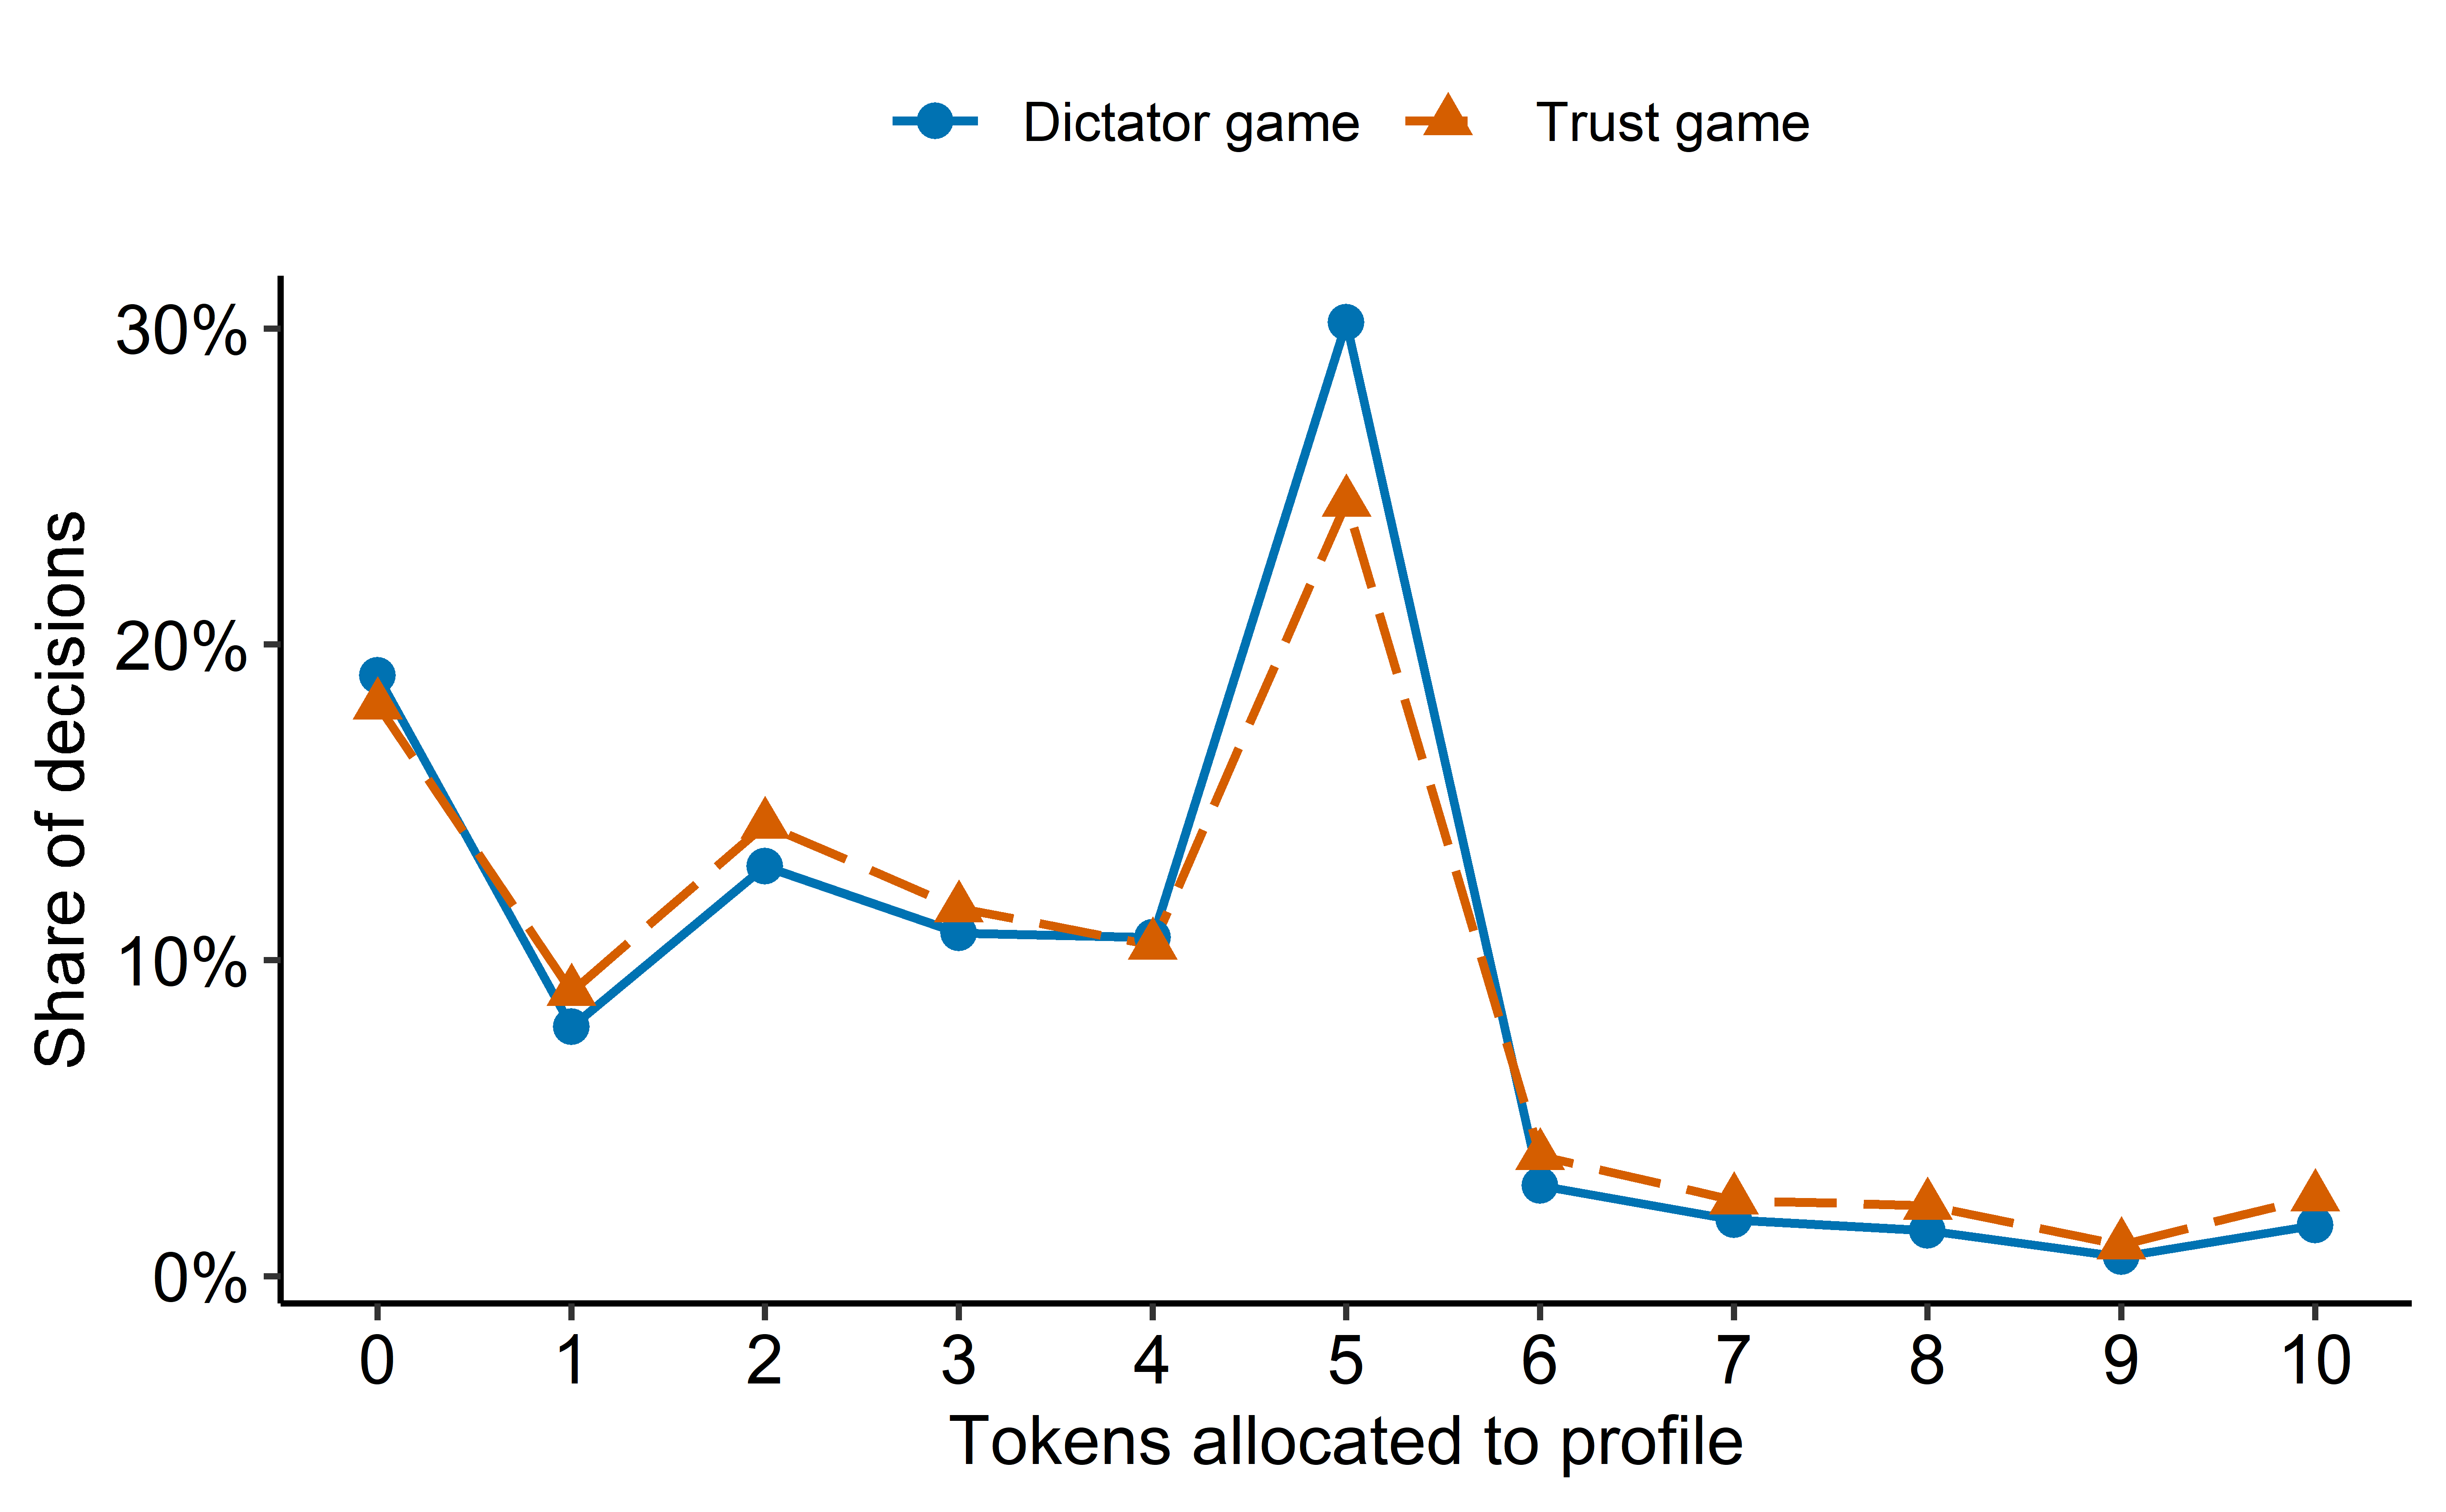

In [ ]:
#| label: fig-outcome-distr
#| fig-cap: "Distribution of outcomes (tokens allocated to the displayed profile) by game. Points are the within-game share of decisions at each integer token value, connected within game. $N=84.603$ in both games."
#| fig-dpi: 500
#| fig-width: 5.5
#| fig-height: 3.4
# within-game share at each integer token value
outcome_distr <- eu25_long |>
  mutate(game = lab_game(cj_game_type)) |>
  count(game, cj_pl2) |>
  group_by(game) |>
  mutate(prop = n / sum(n)) |>
  ungroup()

outcome_distr |>
  ggplot(aes(
    x = cj_pl2,
    y = prop,
    colour = game,
    shape = game,
    linetype = game,
    group = game
  )) +
  geom_line(linewidth = 0.7) +
  geom_point(size = 2.5) +
  scale_colour_game() +
  scale_shape_game() +
  scale_linetype_game() +
  scale_x_continuous(breaks = 0:10) +
  scale_y_continuous(labels = scales::label_percent()) +
  labs(
    x = "Tokens allocated to profile",
    y = "Share of decisions"
  ) +
  theme_mbeu()

## Data Covariate Balance Table

In [ ]:
#| label: tbl-balance-round-mods
#| tbl-cap: "Profile level covariates distributions by treatment. Cells show raw counts with column percentages in parentheses for categorical variables, and the median with the first and third quartiles (Q1, Q3) in parentheses for numeric variables."
prof_mods <- c(
  "cj_nationality_shown",
  "der_cj_eu_identity",
  "der_cj_partisanship",
  "cj_age",
  "cj_sex",
  "cj_class"
)
resp_mods <- c(
  "q_gender",
  "q_age",
  "q_identity_country",
  "q_identity_eu",
  "q_identity_europe",
  "q_religion",
  "q_class",
  "q_eu_efficacy_understand",
  "q_pop_reps",
  "q_pop_goodevil",
  "q_pop_compromise",
  "q_dem_compromise",
  "q_dem_listen",
  "q_tech_experts",
  "q_tech_leaders",
  "q_party_harm",
  "q_people_incompetent",
  "q_eu_longterm",
  "q_eu_responsive",
  "q_eu_imp_nat_econ",
  "q_eu_imp_nat_cul",
  "q_eu_imp_nat_pol",
  "q_eu_abolish",
  "q_eu_satisfaction",
  "q_rural_urban",
  "q_edu_age_stop"
)
all_mods <- c(prof_mods, resp_mods)

eu25_long |>
  mutate(
    treat = factor(
      if_else(cj_rel == "muslim", "Muslim", "Non-Muslim"),
      levels = c("Non-Muslim", "Muslim")
    )
  ) |>
  select(
    all_of(prof_mods),
    treat
  ) |>
  tbl_summary(
    by = treat
  ) |>
  modify_header(
    label = "**Variable**"
  ) |>
  as_kable()

  --------------------------------------------------------------------------
  **Variable**           **Non-Muslim** N = 126,663   **Muslim** N = 42,543
  ---------------------- --------------------------- -----------------------
  cj_nationality_shown                               

  eu                            31,546 (25%)              10,572 (25%)

  non_eu                        8,660 (6.8%)              2,988 (7.0%)

  own_country                   86,457 (68%)              28,983 (68%)

  der_cj_eu_identity                                 

  eu_citizen                    34,470 (27%)              11,558 (27%)

  not_displayed                 57,469 (45%)              19,544 (46%)

  not_eu_citizen                34,724 (27%)              11,441 (27%)

  der_cj_partisanship                                

  not_applicable                40,206 (32%)              13,560 (32%)

  not_shown                     17,130 (14%)               5,874 (14%)

  shown                         69,327 (55%)              23,109 (54%)

  cj_age                                             

  18                            25,347 (20%)               8,539 (20%)

  30                            25,348 (20%)               8,373 (20%)

  42                            25,244 (20%)               8,611 (20%)

  53                            25,521 (20%)               8,622 (20%)

  65                            25,203 (20%)               8,398 (20%)

  cj_sex                                             

  female                        63,308 (50%)              21,338 (50%)

  male                          63,355 (50%)              21,205 (50%)

  cj_class                                           

  lower                         42,023 (33%)              14,048 (33%)

  middle                        42,393 (33%)              14,294 (34%)

  upper                         42,247 (33%)              14,201 (33%)
  --------------------------------------------------------------------------


In [ ]:
#| label: tbl-balance-resp-mods
#| tbl-cap: "Individual level covariate distributions by treatment. Cells show raw counts with column percentages in parentheses for categorical variables, and the median with the first and third quartiles (Q1, Q3) in parentheses for numeric variables."
#| warning: false
#| message: false
eu25_long |>
  mutate(
    treat = factor(
      if_else(cj_rel == "muslim", "Muslim", "Non-Muslim"),
      levels = c("Non-Muslim", "Muslim")
    )
  ) |>
  select(
    all_of(resp_mods),
    treat,
    meta_pid
  ) |>
  distinct(meta_pid, .keep_all = T) |>
  select(-meta_pid) |>
  tbl_summary(
    by = treat,
    type = list(
      q_age ~ "continuous",
      q_identity_country ~ "continuous",
      q_identity_eu ~ "continuous",
      q_identity_europe ~ "continuous",
      q_eu_efficacy_understand ~ "continuous",
      q_pop_reps ~ "continuous",
      q_pop_goodevil ~ "continuous",
      q_pop_compromise ~ "continuous",
      q_dem_compromise ~ "continuous",
      q_dem_listen ~ "continuous",
      q_tech_experts ~ "continuous",
      q_tech_leaders ~ "continuous",
      q_party_harm ~ "continuous",
      q_people_incompetent ~ "continuous",
      q_eu_longterm ~ "continuous",
      q_eu_responsive ~ "continuous",
      q_eu_imp_nat_econ ~ "continuous",
      q_eu_imp_nat_cul ~ "continuous",
      q_eu_imp_nat_pol ~ "continuous",
      q_eu_abolish ~ "continuous",
      q_eu_satisfaction ~ "continuous",
      q_edu_age_stop ~ "continuous"
    )
  ) |>
  modify_header(
    label = "**Variable**"
  ) |>
  as_kable()

  ---------------------------------------------------------------------------
  **Variable**               **Non-Muslim** N = 16,622  **Muslim** N = 5,537
  -------------------------- -------------------------- ---------------------
  q_gender                                              

  female                            8,770 (53%)              2,985 (54%)

  male                              7,826 (47%)              2,548 (46%)

  other                              26 (0.2%)               4 (\<0.1%)

  q_age                             46 (34, 57)              46 (34, 58)

  q_identity_country                  1 (1, 2)                1 (1, 2)

  q_identity_eu                       3 (2, 4)                3 (2, 4)

  q_identity_europe                   2 (2, 3)                2 (2, 3)

  q_religion                                            

  atheist                           1,996 (12%)               634 (11%)

  buddhist                           64 (0.4%)                20 (0.4%)

  catholic                          5,592 (34%)              1,911 (35%)

  dont_know                          687 (4.1%)              209 (3.8%)

  hindu                              22 (0.1%)               2 (\<0.1%)

  jewish                             37 (0.2%)                9 (0.2%)

  muslim                             80 (0.5%)                33 (0.6%)

  nonbeliever_agnostic              3,559 (21%)              1,214 (22%)

  orthodox                          1,823 (11%)               570 (10%)

  other                              589 (3.5%)              177 (3.2%)

  other_christian                    729 (4.4%)              239 (4.3%)

  protestant                        1,439 (8.7%)             518 (9.4%)

  sikh                               5 (\<0.1%)              1 (\<0.1%)

  q_class                                               

  dont_know                          540 (3.2%)              210 (3.8%)

  higher_class                       106 (0.6%)               35 (0.6%)

  lower_middle_class                3,217 (19%)              1,088 (20%)

  middle_class                      7,848 (47%)              2,537 (46%)

  other                              7 (\<0.1%)              2 (\<0.1%)

  upper_middle_class                1,541 (9.3%)             551 (10.0%)

  working_class                     3,363 (20%)              1,114 (20%)

  q_eu_efficacy_understand            5 (4, 6)                5 (4, 6)

  q_pop_reps                          6 (5, 7)                6 (5, 7)

  q_pop_goodevil                      4 (3, 5)                4 (3, 5)

  q_pop_compromise                    5 (4, 6)                5 (4, 6)

  q_dem_compromise                    5 (5, 6)                5 (5, 6)

  q_dem_listen                        6 (5, 7)                6 (5, 7)

  q_tech_experts                      5 (4, 6)                5 (4, 6)

  q_tech_leaders                      6 (5, 7)                6 (5, 7)

  q_party_harm                        5 (4, 6)                5 (4, 6)

  q_people_incompetent                4 (3, 5)                4 (3, 6)

  q_eu_longterm                       5 (4, 6)                5 (4, 6)

  q_eu_responsive                     6 (5, 7)                6 (5, 7)

  q_eu_imp_nat_econ                   3 (2, 3)                3 (2, 3)

  q_eu_imp_nat_cul                    3 (2, 4)                3 (2, 4)

  q_eu_imp_nat_pol                    3 (2, 4)                3 (2, 4)

  q_eu_abolish                        5 (3, 6)                5 (3, 6)

  q_eu_satisfaction                   4 (3, 5)                4 (3, 5)

  q_rural_urban                                         

  large_city                        6,320 (38%)              2,123 (38%)

  rural                             2,969 (18%)              1,042 (19%)

  small_med_town                    7,333 (44%)              2,372 (43%)

  q_edu_age_stop                 21.0 (18.0, 24.0)        21.0 (18.0, 24.0)
  ---------------------------------------------------------------------------


## Survey Item Reference Table

In [ ]:
#| label: tbl-wordings
#| tbl-cap: "Question wordings and scales of individual-level covariates used in the analysis."
# fmt: skip
tibble::tribble(
  ~Variable, ~`Question wording`, ~`Scale coding`,
  "`q_gender`", "Please indicate your gender.", "Categorical",
  "`q_religion`", "Do you consider yourself to be…?", "Categorical",
  "`q_class`", "Do you see yourself and your household belonging to...?", "Categorical",
  "`q_rural_urban`", "Would you say you live in a…?", "Categorical",
  "`q_identity_country`", "Please tell me how attached you feel to... - [SURVEY COUNTRY]", "1 (very attached) to 5 (not at all attached)",
  "`q_identity_eu`", "Please tell me how attached you feel to... - The European Union (EU)", "1 (very attached) to 5 (not at all attached)",
  "`q_identity_europe`", "Please tell me how attached you feel to... - Europe", "1 (very attached) to 5 (not at all attached)",
  "`q_eu_efficacy_understand`", "Please tell me to what extent you agree or disagree with each of the following statements. - I can understand and evaluate important political questions about the EU", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_pop_reps`", "Please indicate how much you agree with each of the following statements. - Elected officials talk too much and take too little action.", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_pop_goodevil`", "Please indicate how much you agree with each of the following statements. - Politics is ultimately a struggle between good and evil.", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_pop_compromise`", "Please indicate how much you agree with each of the following statements. - What people call \"compromise\" in politics is really just selling out on one's principles.", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_dem_compromise`", "Please indicate how much you agree with each of the following statements. - In a democracy it is important to make compromises among differing viewpoints.", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_age`", "How old are you?", "Age in years",
  "`q_dem_listen`", "Please indicate how much you agree with each of the following statements. - It is important to listen to the opinion of other groups.", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_tech_experts`", "Please indicate how much you agree with each of the following statements. - Our country would run better if political decisions were left up to experts instead of politicians and citizens.", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_tech_leaders`", "Please indicate how much you agree with each of the following statements. - The leaders of our country should be more educated and skilled than ordinary citizens.", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_party_harm`", "Please indicate how much you agree with each of the following statements. - Political parties do more harm than good to society", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_people_incompetent`", "Please indicate how much you agree with each of the following statements. - Ordinary people don't know what policies are good for them.", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_eu_longterm`", "In thinking about the European Union (EU) and its decisions more generally, some people argue that it should act upon its long-term goals without pandering to the demand of the people. On the other hand, others argue that the EU should listen to the demand of people, rather than to act upon its long-term goals. When it comes to the question of whether the EU should act upon its long-term goals or it should listen to the demand of the people, what is your opinion? - The EU should act upon its long-term goals", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_eu_responsive`", "In thinking about the European Union (EU) and its decisions more generally, some people argue that it should act upon its long-term goals without pandering to the demand of the people. On the other hand, others argue that the EU should listen to the demand of people, rather than to act upon its long-term goals. When it comes to the question of whether the EU should act upon its long-term goals or it should listen to the demand of the people, what is your opinion? - The EU should listen to the demand of the people", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_eu_imp_nat_econ`", "Could you tell me whether you think that the EU has a rather positive or rather negative effect on each of the following domains? - UK economy", "1 (very positive) to 5 (very negative)",
  "`q_eu_imp_nat_cul`", "Could you tell me whether you think that the EU has a rather positive or rather negative effect on each of the following domains? - Our culture and identity", "1 (very positive) to 5 (very negative)",
  "`q_eu_imp_nat_pol`", "Could you tell me whether you think that the EU has a rather positive or rather negative effect on each of the following domains? - UK's political status and influence", "1 (very positive) to 5 (very negative)",
  "`q_eu_abolish`", "Please tell me to what extent you agree or disagree with each of the following statements. - If the EU started making a lot of decisions that most people disagreed with, it might be better to do away with the EU altogether", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_eu_satisfaction`", "Please tell me to what extent you agree or disagree with each of the following statements. - I am satisfied with the performance of the EU", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_edu_age_stop`", "How old were you when you stopped full-time education?", "Years"
) |>
  knitr::kable()

  ---------------------------------------------------------------------------------------------------------
  Variable                     Question wording                                               Scale coding
  ---------------------------- -------------------------------------------------------------- -------------
  `q_gender`                   Please indicate your gender.                                   Categorical

  `q_religion`                 Do you consider yourself to be...?                             Categorical

  `q_class`                    Do you see yourself and your household belonging to...?        Categorical

  `q_rural_urban`              Would you say you live in a...?                                Categorical

  `q_identity_country`         Please tell me how attached you feel to... - \[SURVEY          1 (very
                               COUNTRY\]                                                      attached) to
                                                                                              5 (not at all
                                                                                              attached)

  `q_identity_eu`              Please tell me how attached you feel to... - The European      1 (very
                               Union (EU)                                                     attached) to
                                                                                              5 (not at all
                                                                                              attached)

  `q_identity_europe`          Please tell me how attached you feel to... - Europe            1 (very
                                                                                              attached) to
                                                                                              5 (not at all
                                                                                              attached)

  `q_eu_efficacy_understand`   Please tell me to what extent you agree or disagree with each  1 (strongly
                               of the following statements. - I can understand and evaluate   disagree) to
                               important political questions about the EU                     7 (strongly
                                                                                              agree)

  `q_pop_reps`                 Please indicate how much you agree with each of the following  1 (strongly
                               statements. - Elected officials talk too much and take too     disagree) to
                               little action.                                                 7 (strongly
                                                                                              agree)

  `q_pop_goodevil`             Please indicate how much you agree with each of the following  1 (strongly
                               statements. - Politics is ultimately a struggle between good   disagree) to
                               and evil.                                                      7 (strongly
                                                                                              agree)

  `q_pop_compromise`           Please indicate how much you agree with each of the following  1 (strongly
                               statements. - What people call "compromise" in politics is     disagree) to
                               really just selling out on one's principles.                   7 (strongly
                                                                                              agree)

  `q_dem_compromise`           Please indicate how much you agree with each of the following  1 (strongly
                               statements. - In a democracy it is important to make           disagree) to
                               compromises among differing viewpoints.                        7 (strongly
                                                                                              agree)

  `q_age`                      How old are you?                                               Age in years

  `q_dem_listen`               Please indicate how much you agree with each of the following  1 (strongly
                               statements. - It is important to listen to the opinion of      disagree) to
                               other groups.                                                  7 (strongly
                                                                                              agree)

  `q_tech_experts`             Please indicate how much you agree with each of the following  1 (strongly
                               statements. - Our country would run better if political        disagree) to
                               decisions were left up to experts instead of politicians and   7 (strongly
                               citizens.                                                      agree)

  `q_tech_leaders`             Please indicate how much you agree with each of the following  1 (strongly
                               statements. - The leaders of our country should be more        disagree) to
                               educated and skilled than ordinary citizens.                   7 (strongly
                                                                                              agree)

  `q_party_harm`               Please indicate how much you agree with each of the following  1 (strongly
                               statements. - Political parties do more harm than good to      disagree) to
                               society                                                        7 (strongly
                                                                                              agree)

  `q_people_incompetent`       Please indicate how much you agree with each of the following  1 (strongly
                               statements. - Ordinary people don't know what policies are     disagree) to
                               good for them.                                                 7 (strongly
                                                                                              agree)

  `q_eu_longterm`              In thinking about the European Union (EU) and its decisions    1 (strongly
                               more generally, some people argue that it should act upon its  disagree) to
                               long-term goals without pandering to the demand of the people. 7 (strongly
                               On the other hand, others argue that the EU should listen to   agree)
                               the demand of people, rather than to act upon its long-term    
                               goals. When it comes to the question of whether the EU should  
                               act upon its long-term goals or it should listen to the demand 
                               of the people, what is your opinion? - The EU should act upon  
                               its long-term goals                                            

  `q_eu_responsive`            In thinking about the European Union (EU) and its decisions    1 (strongly
                               more generally, some people argue that it should act upon its  disagree) to
                               long-term goals without pandering to the demand of the people. 7 (strongly
                               On the other hand, others argue that the EU should listen to   agree)
                               the demand of people, rather than to act upon its long-term    
                               goals. When it comes to the question of whether the EU should  
                               act upon its long-term goals or it should listen to the demand 
                               of the people, what is your opinion? - The EU should listen to 
                               the demand of the people                                       

  `q_eu_imp_nat_econ`          Could you tell me whether you think that the EU has a rather   1 (very
                               positive or rather negative effect on each of the following    positive) to
                               domains? - UK economy                                          5 (very
                                                                                              negative)

  `q_eu_imp_nat_cul`           Could you tell me whether you think that the EU has a rather   1 (very
                               positive or rather negative effect on each of the following    positive) to
                               domains? - Our culture and identity                            5 (very
                                                                                              negative)

  `q_eu_imp_nat_pol`           Could you tell me whether you think that the EU has a rather   1 (very
                               positive or rather negative effect on each of the following    positive) to
                               domains? - UK's political status and influence                 5 (very
                                                                                              negative)

  `q_eu_abolish`               Please tell me to what extent you agree or disagree with each  1 (strongly
                               of the following statements. - If the EU started making a lot  disagree) to
                               of decisions that most people disagreed with, it might be      7 (strongly
                               better to do away with the EU altogether                       agree)

  `q_eu_satisfaction`          Please tell me to what extent you agree or disagree with each  1 (strongly
                               of the following statements. - I am satisfied with the         disagree) to
                               performance of the EU                                          7 (strongly
                                                                                              agree)

  `q_edu_age_stop`             How old were you when you stopped full-time education?         Years
  ---------------------------------------------------------------------------------------------------------


## Session Info

In [ ]:
#| label: session-info
#| eval: true
#| echo: true
session_info()

─ Session info ───────────────────────────────────────────────────────────────
 setting  value
 version  R version 4.5.3 (2026-03-11 ucrt)
 os       Windows 11 x64 (build 26200)
 system   x86_64, mingw32
 ui       RTerm
 language (EN)
 collate  English_United States.utf8
 ctype    English_United States.utf8
 tz       Europe/Berlin
 date     2026-06-12
 pandoc   3.8.3 @ c:\\Program Files\\Positron\\resources\\app\\quarto\\bin\\tools/ (via rmarkdown)
 quarto   1.9.36 @ C:\\PROGRA~1\\Quarto\\bin\\quarto.exe

─ Packages ───────────────────────────────────────────────────────────────────
 package      * version    date (UTC) lib source
 abind          1.4-8      2024-09-12 [1] CRAN (R 4.5.0)
 backports      1.5.0      2024-05-23 [1] CRAN (R 4.5.0)
 broom          1.0.11     2025-12-04 [1] CRAN (R 4.5.2)
 car            3.1-3      2024-09-27 [1] CRAN (R 4.5.1)
 carData        3.0-5      2022-01-06 [1] CRAN (R 4.5.1)
 cards          0.7.1      2025-12-02 [1] CRAN (R 4.5.2)
 cli            3.6

## Execution Time

In [ ]:
#| label: exec-time
#| eval: true
#| echo: true
#| include: true
end_time <- Sys.time()
exec_time <- end_time - start_time
cat(paste(
  "R code execution time:",
  round(as.numeric(exec_time, units = "secs"), 2),
  "seconds."
))

R code execution time: 13.53 seconds.

```` markdown
---
title: "Additional Figures & Tables"
subtitle: |
  Main Figures and Tables
date: last-modified
date-format: MMMM D, YYYY
format:
  html:
    toc: true
    code-fold: true
    code-tools: true
execute:
  echo: true
  warning: true
  eval: true
  message: true
---

## Setup {#sec-setup}

quarto-executable-code-5450563D

```r
#| label: setup
#| include: false
# execution time
start_time <- Sys.time()
# console width
options(width = 80)
# packages
p_required <- c(
  "tidyverse", # dplyr, ggplot2, tidyr
  "here", # relative paths
  "ggpubr", # theme_pubr
  "patchwork", # multi-panel composition
  "gtsummary",
  "gt",
  "sessioninfo" # session docs
)
packages <- rownames(installed.packages())
p_to_install <- p_required[!(p_required %in% packages)]
if (length(p_to_install) > 0) {
  install.packages(p_to_install)
}
sapply(p_required, require, character.only = TRUE)
rm(p_required, p_to_install, packages)
```

## Load long format data {#sec-code-1}

quarto-executable-code-5450563D

```r
#| label: load-dat
eu25_long <- read_rds(
  here(
    "data",
    "02_processed",
    "eu25_long.rds"
  )
)
```

## House style {#sec-house}

The shared visual grammar for every figure in this notebook.
The two games are the only thing encoded by colour, shape, and linetype, and they are always
encoded by all three at once, so each game is distinguishable in colour, in greyscale print,
and under colourblindness.
Any other categorical distinction (moderator family, estimator, treatment level) is carried by
facets, panels, or axis position — never by reusing a game channel.

quarto-executable-code-5450563D

```r
#| label: game-style
# game identity: Okabe-Ito blue / orange, redundant shape + linetype
game_labs <- c(cj_dict = "Dictator game", cj_trust = "Trust game")
game_cols <- c("Dictator game" = "#0072B2", "Trust game" = "#D55E00")
game_shapes <- c("Dictator game" = 16, "Trust game" = 17) # circle / triangle
game_ltys <- c("Dictator game" = "solid", "Trust game" = "longdash")

# raw cj_game_type -> ordered, human-readable factor
lab_game <- function(x) {
  factor(unname(game_labs[as.character(x)]), levels = unname(game_labs))
}
```

The three reserved scales are always added together so the legend collapses to one key.

quarto-executable-code-5450563D

```r
#| label: game-scales
scale_colour_game <- function() {
  scale_colour_manual(values = game_cols, name = NULL)
}
scale_shape_game <- function() {
  scale_shape_manual(values = game_shapes, name = NULL)
}
scale_linetype_game <- function() {
  scale_linetype_manual(values = game_ltys, name = NULL)
}
```

Shared theme, reference layers, dodge width, and the common CATE y-axis label.

quarto-executable-code-5450563D

```r
#| label: house-theme
theme_mbeu <- function(base_size = 11) {
  ggpubr::theme_pubr(base_size = base_size) +
    theme(legend.position = "top")
}
# dashed null line for effect figures
ref_zero <- geom_hline(yintercept = 0, linetype = "dashed", colour = "grey60")
# side-by-side offset for two-game overlays
dodge <- position_dodge(width = 0.5)
# shared axis label for CATE-by-moderator figures
yl_cate <- "CATE (effect of Muslim profile)"
```

The golden ratio is the default figure aspect (width : height ≈ 1.618 : 1).
Set chunk `fig-width`/`fig-height` from `golden` so single-panel figures share one proportion;
do not apply it to faceted small multiples or auto-sized contexts.

quarto-executable-code-5450563D

```r
#| label: golden-ratio
golden <- (1 + sqrt(5)) / 2 # ~1.618
# figure height (in) for a given width at golden proportion
golden_h <- function(width) width / golden
```

## Token allocation to Muslim profiles {#sec-diff-means}

The motivating descriptive: how many tokens does a profile receive when it is
labelled Muslim versus everything else, in each game.
We summarise this three ways — a per-game Welch two-sample t-test on the raw
difference in means (the sample average treatment effect, SATE), a
slope/dumbbell figure of the two group means with 95% confidence intervals, and
a one-row-per-game summary table of the same quantities (the version embedded
in the manuscript).
The test is intentionally simple and descriptive: respondent clustering is left
to the heterogeneity models that follow.

quarto-executable-code-5450563D

```r
#| label: diff-in-means-test
# analysis frame: muslim vs all-else, readable game
dim_dat <- eu25_long |>
  mutate(
    treat = factor(
      if_else(cj_rel == "muslim", "Muslim", "Non-Muslim"),
      levels = c("Non-Muslim", "Muslim")
    ),
    game = lab_game(cj_game_type)
  )

# welch t-test per game, muslim - non-muslim
dim_test_one <- function(df) {
  tt <- t.test(cj_pl2 ~ treat, data = df) # non-muslim - muslim
  tibble(
    mean_nonmuslim = unname(tt$estimate[1]),
    mean_muslim = unname(tt$estimate[2]),
    diff = mean_muslim - mean_nonmuslim,
    conf_low = -tt$conf.int[2],
    conf_high = -tt$conf.int[1],
    t = -unname(tt$statistic),
    df = unname(tt$parameter),
    p = tt$p.value
  )
}

dim_tests <- dim_dat |>
  group_by(game) |>
  group_modify(~ dim_test_one(.x)) |>
  ungroup()

dim_tests
```

Read the SATE numbers off `dim_tests` above and fill the placeholders in the
figure caption.

quarto-executable-code-5450563D

```r
#| label: fig-diff-in-means
#| fig-cap: "Mean tokens allocated to a profile by the Muslim label, by game. The outcome (y-axis) is the number of tokens the respondent allocates to the displayed profile. X-axis contrasts profiles labelled Muslim against all other religions pooled. Points are group means and error bars are 95% confidence intervals. The slope of each line is the sample average treatment effect (SATE) of the Muslim label, estimated by a per-game Welch two-sample difference-in-means t-test: $\\widehat{\\text{SATE}}_\\text{Dictator} = -0.57\\ [-0.61, -0.53]$, $\\widehat{\\text{SATE}}_\\text{Trust} = -0.64\\ [-0.68, -0.61]$."
#| fig-dpi: 500
#| fig-width: 5.5
#| fig-height: 3.4
# group means + 95% ci
dim_means <- dim_dat |>
  group_by(game, treat) |>
  summarise(
    mean_tok = mean(cj_pl2),
    se = sd(cj_pl2) / sqrt(n()),
    ci = qt(0.975, n() - 1) * se,
    .groups = "drop"
  )

dim_means |>
  ggplot(aes(
    x = treat,
    y = mean_tok,
    colour = game,
    shape = game,
    linetype = game,
    group = game
  )) +
  geom_line(position = dodge, linewidth = 0.7) +
  geom_errorbar(
    aes(ymin = mean_tok - ci, ymax = mean_tok + ci),
    position = dodge,
    width = 0.08,
    linewidth = 0.4,
    linetype = "solid"
  ) +
  geom_point(position = dodge, size = 3) +
  scale_colour_game() +
  scale_shape_game() +
  scale_linetype_game() +
  labs(
    title = "Muslim profiles receive fewer tokens in both games",
    x = NULL,
    y = "Mean tokens allocated"
  ) +
  theme_mbeu()
```

The summary table condenses the figure into one row per game: the two group
means with their 95% confidence intervals, the per-game SATE from `dim_tests`,
and its 95% confidence interval.

quarto-executable-code-5450563D

```r
#| label: tbl-diff-in-means
#| tbl-cap: "Mean tokens allocated to a profile by the Muslim label, by game. The outcome is the number of tokens the respondent allocates to the displayed profile. Profiles labelled Muslim are contrasted against all other religions pooled. The first two columns show group means with 95% confidence intervals in brackets. The SATE column reports the sample average treatment effect of the Muslim label, estimated by a per-game Welch two-sample difference-in-means t-test, with its 95% confidence interval alongside. The test is intentionally simple and descriptive. Respondent clustering is left to the heterogeneity models."
# one row per game: group means [ci], sate, sate ci
dim_means |>
  mutate(
    cell = sprintf("%.2f [%.2f, %.2f]", mean_tok, mean_tok - ci, mean_tok + ci)
  ) |>
  select(game, treat, cell) |>
  pivot_wider(names_from = treat, values_from = cell) |>
  left_join(dim_tests, by = "game") |>
  transmute(
    Game = game,
    Muslim,
    `Non-Muslim`,
    SATE = sprintf("%.2f", diff),
    `95% CI` = sprintf("[%.2f, %.2f]", conf_low, conf_high)
  ) |>
  knitr::kable()
```


## Outcome Distribution

The distribution of the raw outcome — tokens allocated to the displayed profile,
an integer from 0 to 10 — in each game.
Both games are drawn together with the reserved colour/shape/linetype grammar applied at
once, and shown as within-game proportions so the two games are comparable despite differing
numbers of decisions.

quarto-executable-code-5450563D

```r
#| label: fig-outcome-distr
#| fig-cap: "Distribution of outcomes (tokens allocated to the displayed profile) by game. Points are the within-game share of decisions at each integer token value, connected within game. $N=84.603$ in both games."
#| fig-dpi: 500
#| fig-width: 5.5
#| fig-height: 3.4
# within-game share at each integer token value
outcome_distr <- eu25_long |>
  mutate(game = lab_game(cj_game_type)) |>
  count(game, cj_pl2) |>
  group_by(game) |>
  mutate(prop = n / sum(n)) |>
  ungroup()

outcome_distr |>
  ggplot(aes(
    x = cj_pl2,
    y = prop,
    colour = game,
    shape = game,
    linetype = game,
    group = game
  )) +
  geom_line(linewidth = 0.7) +
  geom_point(size = 2.5) +
  scale_colour_game() +
  scale_shape_game() +
  scale_linetype_game() +
  scale_x_continuous(breaks = 0:10) +
  scale_y_continuous(labels = scales::label_percent()) +
  labs(
    x = "Tokens allocated to profile",
    y = "Share of decisions"
  ) +
  theme_mbeu()
```

## Data Covariate Balance Table

quarto-executable-code-5450563D

```r
#| label: tbl-balance-round-mods
#| tbl-cap: "Profile level covariates distributions by treatment. Cells show raw counts with column percentages in parentheses for categorical variables, and the median with the first and third quartiles (Q1, Q3) in parentheses for numeric variables."
prof_mods <- c(
  "cj_nationality_shown",
  "der_cj_eu_identity",
  "der_cj_partisanship",
  "cj_age",
  "cj_sex",
  "cj_class"
)
resp_mods <- c(
  "q_gender",
  "q_age",
  "q_identity_country",
  "q_identity_eu",
  "q_identity_europe",
  "q_religion",
  "q_class",
  "q_eu_efficacy_understand",
  "q_pop_reps",
  "q_pop_goodevil",
  "q_pop_compromise",
  "q_dem_compromise",
  "q_dem_listen",
  "q_tech_experts",
  "q_tech_leaders",
  "q_party_harm",
  "q_people_incompetent",
  "q_eu_longterm",
  "q_eu_responsive",
  "q_eu_imp_nat_econ",
  "q_eu_imp_nat_cul",
  "q_eu_imp_nat_pol",
  "q_eu_abolish",
  "q_eu_satisfaction",
  "q_rural_urban",
  "q_edu_age_stop"
)
all_mods <- c(prof_mods, resp_mods)

eu25_long |>
  mutate(
    treat = factor(
      if_else(cj_rel == "muslim", "Muslim", "Non-Muslim"),
      levels = c("Non-Muslim", "Muslim")
    )
  ) |>
  select(
    all_of(prof_mods),
    treat
  ) |>
  tbl_summary(
    by = treat
  ) |>
  modify_header(
    label = "**Variable**"
  ) |>
  as_kable()
```

quarto-executable-code-5450563D

```r
#| label: tbl-balance-resp-mods
#| tbl-cap: "Individual level covariate distributions by treatment. Cells show raw counts with column percentages in parentheses for categorical variables, and the median with the first and third quartiles (Q1, Q3) in parentheses for numeric variables."
#| warning: false
#| message: false
eu25_long |>
  mutate(
    treat = factor(
      if_else(cj_rel == "muslim", "Muslim", "Non-Muslim"),
      levels = c("Non-Muslim", "Muslim")
    )
  ) |>
  select(
    all_of(resp_mods),
    treat,
    meta_pid
  ) |>
  distinct(meta_pid, .keep_all = T) |>
  select(-meta_pid) |>
  tbl_summary(
    by = treat,
    type = list(
      q_age ~ "continuous",
      q_identity_country ~ "continuous",
      q_identity_eu ~ "continuous",
      q_identity_europe ~ "continuous",
      q_eu_efficacy_understand ~ "continuous",
      q_pop_reps ~ "continuous",
      q_pop_goodevil ~ "continuous",
      q_pop_compromise ~ "continuous",
      q_dem_compromise ~ "continuous",
      q_dem_listen ~ "continuous",
      q_tech_experts ~ "continuous",
      q_tech_leaders ~ "continuous",
      q_party_harm ~ "continuous",
      q_people_incompetent ~ "continuous",
      q_eu_longterm ~ "continuous",
      q_eu_responsive ~ "continuous",
      q_eu_imp_nat_econ ~ "continuous",
      q_eu_imp_nat_cul ~ "continuous",
      q_eu_imp_nat_pol ~ "continuous",
      q_eu_abolish ~ "continuous",
      q_eu_satisfaction ~ "continuous",
      q_edu_age_stop ~ "continuous"
    )
  ) |>
  modify_header(
    label = "**Variable**"
  ) |>
  as_kable()
```

## Survey Item Reference Table {#sec-survey-items}

quarto-executable-code-5450563D

```r
#| label: tbl-wordings
#| tbl-cap: "Question wordings and scales of individual-level covariates used in the analysis."
# fmt: skip
tibble::tribble(
  ~Variable, ~`Question wording`, ~`Scale coding`,
  "`q_gender`", "Please indicate your gender.", "Categorical",
  "`q_religion`", "Do you consider yourself to be…?", "Categorical",
  "`q_class`", "Do you see yourself and your household belonging to...?", "Categorical",
  "`q_rural_urban`", "Would you say you live in a…?", "Categorical",
  "`q_identity_country`", "Please tell me how attached you feel to... - [SURVEY COUNTRY]", "1 (very attached) to 5 (not at all attached)",
  "`q_identity_eu`", "Please tell me how attached you feel to... - The European Union (EU)", "1 (very attached) to 5 (not at all attached)",
  "`q_identity_europe`", "Please tell me how attached you feel to... - Europe", "1 (very attached) to 5 (not at all attached)",
  "`q_eu_efficacy_understand`", "Please tell me to what extent you agree or disagree with each of the following statements. - I can understand and evaluate important political questions about the EU", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_pop_reps`", "Please indicate how much you agree with each of the following statements. - Elected officials talk too much and take too little action.", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_pop_goodevil`", "Please indicate how much you agree with each of the following statements. - Politics is ultimately a struggle between good and evil.", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_pop_compromise`", "Please indicate how much you agree with each of the following statements. - What people call \"compromise\" in politics is really just selling out on one's principles.", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_dem_compromise`", "Please indicate how much you agree with each of the following statements. - In a democracy it is important to make compromises among differing viewpoints.", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_age`", "How old are you?", "Age in years",
  "`q_dem_listen`", "Please indicate how much you agree with each of the following statements. - It is important to listen to the opinion of other groups.", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_tech_experts`", "Please indicate how much you agree with each of the following statements. - Our country would run better if political decisions were left up to experts instead of politicians and citizens.", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_tech_leaders`", "Please indicate how much you agree with each of the following statements. - The leaders of our country should be more educated and skilled than ordinary citizens.", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_party_harm`", "Please indicate how much you agree with each of the following statements. - Political parties do more harm than good to society", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_people_incompetent`", "Please indicate how much you agree with each of the following statements. - Ordinary people don't know what policies are good for them.", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_eu_longterm`", "In thinking about the European Union (EU) and its decisions more generally, some people argue that it should act upon its long-term goals without pandering to the demand of the people. On the other hand, others argue that the EU should listen to the demand of people, rather than to act upon its long-term goals. When it comes to the question of whether the EU should act upon its long-term goals or it should listen to the demand of the people, what is your opinion? - The EU should act upon its long-term goals", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_eu_responsive`", "In thinking about the European Union (EU) and its decisions more generally, some people argue that it should act upon its long-term goals without pandering to the demand of the people. On the other hand, others argue that the EU should listen to the demand of people, rather than to act upon its long-term goals. When it comes to the question of whether the EU should act upon its long-term goals or it should listen to the demand of the people, what is your opinion? - The EU should listen to the demand of the people", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_eu_imp_nat_econ`", "Could you tell me whether you think that the EU has a rather positive or rather negative effect on each of the following domains? - UK economy", "1 (very positive) to 5 (very negative)",
  "`q_eu_imp_nat_cul`", "Could you tell me whether you think that the EU has a rather positive or rather negative effect on each of the following domains? - Our culture and identity", "1 (very positive) to 5 (very negative)",
  "`q_eu_imp_nat_pol`", "Could you tell me whether you think that the EU has a rather positive or rather negative effect on each of the following domains? - UK's political status and influence", "1 (very positive) to 5 (very negative)",
  "`q_eu_abolish`", "Please tell me to what extent you agree or disagree with each of the following statements. - If the EU started making a lot of decisions that most people disagreed with, it might be better to do away with the EU altogether", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_eu_satisfaction`", "Please tell me to what extent you agree or disagree with each of the following statements. - I am satisfied with the performance of the EU", "1 (strongly disagree) to 7 (strongly agree)",
  "`q_edu_age_stop`", "How old were you when you stopped full-time education?", "Years"
) |>
  knitr::kable()
```

## Session Info {#sec-session-info .appendix .unnumbered}

quarto-executable-code-5450563D

```r
#| label: session-info
#| eval: true
#| echo: true
session_info()
```

## Execution Time {#sec-exec-time .appendix .unnumbered}

quarto-executable-code-5450563D

```r
#| label: exec-time
#| eval: true
#| echo: true
#| include: true
end_time <- Sys.time()
exec_time <- end_time - start_time
cat(paste(
  "R code execution time:",
  round(as.numeric(exec_time, units = "secs"), 2),
  "seconds."
))
```
````